# 02 · Spectroscopic completeness of A2199

Spectroscopic completeness f_spec = N(with redshift) / N(all galaxies), as a function of r-band magnitude and of position on the sky, and the redshift distribution of the sample. "Before this study" means redshifts that were already available from Song et al. (2017), SDSS or NED; "This study" adds the new MMT/Hectospec and DESI redshifts.

**Inputs**
- `DATA/AllHeCS_VAC_updated.csv` – HeCS-omnibus cluster catalog (centre, redshift, R200, R500)
- `DATA/A2199/A2199_mastercat_within35arcmin.csv` – A2199 master catalog
- `DATA/A2199/Song2017/z_DATA_8/z_a2199phot21_5DR9_hshwang_35arcmin_Song2017.csv` – Song et al. (2017) redshift catalog (not included)

**Output**: figures only (`A2199_fspec`, `A2199_2Dfspec`, `A2199_spec_z_numbers` in the paper)

In [1]:
# ============================================================================
# Setup
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.cosmology import LambdaCDM

# Cosmology used throughout this project
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)

# Matplotlib style shared by the notebooks of this repository
plt.rcParams.update({
    "font.family": 'STIXGeneral',
    'text.usetex': False,
    "mathtext.fontset": 'cm',
    "axes.labelweight": "normal",
    'font.size': 25,
    'font.weight': 'normal',

    # Ticks: inwards, on all four sides, with minor ticks
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'xtick.major.size': 10,
    'xtick.minor.size': 6,
    'ytick.major.size': 10,
    'ytick.minor.size': 6,
    'xtick.major.width': 1.6,
    'xtick.minor.width': 1.6,
    'ytick.major.width': 1.6,
    'ytick.minor.width': 1.6,

    # Axes and lines
    'lines.linewidth': 2,
    'axes.linewidth': 3.5,
    'axes.labelpad': 4,
    'xtick.major.pad': 7,
    'image.origin': 'lower'
})

# Show every column when a DataFrame is displayed
pd.set_option('display.max_columns', None)

## 0. Load the catalog

Correct magnitudes for Galactic extinction and flag the galaxies whose redshift was already available before this study (Song et al. 2017, SDSS or NED).

In [2]:
# Cluster redshift from the HeCS-omnibus cluster table
hecs_vac_data = pd.read_csv('../../DATA/AllHeCS_VAC_updated.csv')
Z_CLID = hecs_vac_data[hecs_vac_data['CLID'] == 'A2199']['Z'].values[0]

# A2199 master catalog (all SDSS objects within 35 arcmin of the cluster centre)
df0 = pd.read_csv('../../DATA/A2199/A2199_mastercat_within35arcmin.csv')

# Galactic-extinction-corrected model and Petrosian magnitudes (suffix "_0")
for band in ['u', 'g', 'r', 'i', 'z']:
    df0[f'p_modelmag_{band}_0'] = df0[f'p_modelmag_{band}'] - df0[f'p_extinction_{band}']
for band in ['u', 'g', 'r', 'i', 'z']:
    df0[f'p_petromag_{band}_0'] = df0[f'p_petromag_{band}'] - df0[f'p_extinction_{band}']

# Galaxies only, within 35 arcmin
df = df0[(df0['galaxyflag'] == 1) & (df0['p_radgal'] < 35)].copy()

# Song et al. (2017) catalog: objects with an MMT redshift (z_mmt_z != -9)
df_song = pd.read_csv('../../DATA/A2199/Song2017/z_DATA_8/z_a2199phot21_5DR9_hshwang_35arcmin_Song2017.csv')
df_song = df_song[df_song['z_mmt_z'] != -9]
song_objids = set(df_song['p_objid'])

# Song2017_Flag = 'Y' if the redshift was available before this study:
# from SDSS, from NED, or from Song et al. (2017)
df['Song2017_Flag'] = df.apply(
    lambda row: (
        'Y'
        if row['z_tot_zsource'] == 'sdss'
        or row['z_tot_zsource'] == 'ned'
        or row['p_objid'] in song_objids
        else 'N'
    ),
    axis=1
)

## 1. Completeness vs. magnitude (R_cl < 30′)

Top: number of redshifts per 0.2-mag bin. Bottom: f_spec. Dotted vertical lines mark the faintest bin where f_spec > 0.5, before (black) and after (red) this study.

/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_16355/1495775986.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  non99_all = cluster_data.groupby(bin_all)['z_tot_z'].apply(lambda x: (x != -9.0).sum()).values
/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_16355/1495775986.py:16: RuntimeWarning: invalid value encountered in divide
  frac_all = non99_all / total_all
/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_16355/1495775986.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  non99_flag = flagged_data.groupby(bin_flag)['z_tot_z'].apply(lambda x: (x != -9.0).sum()).val

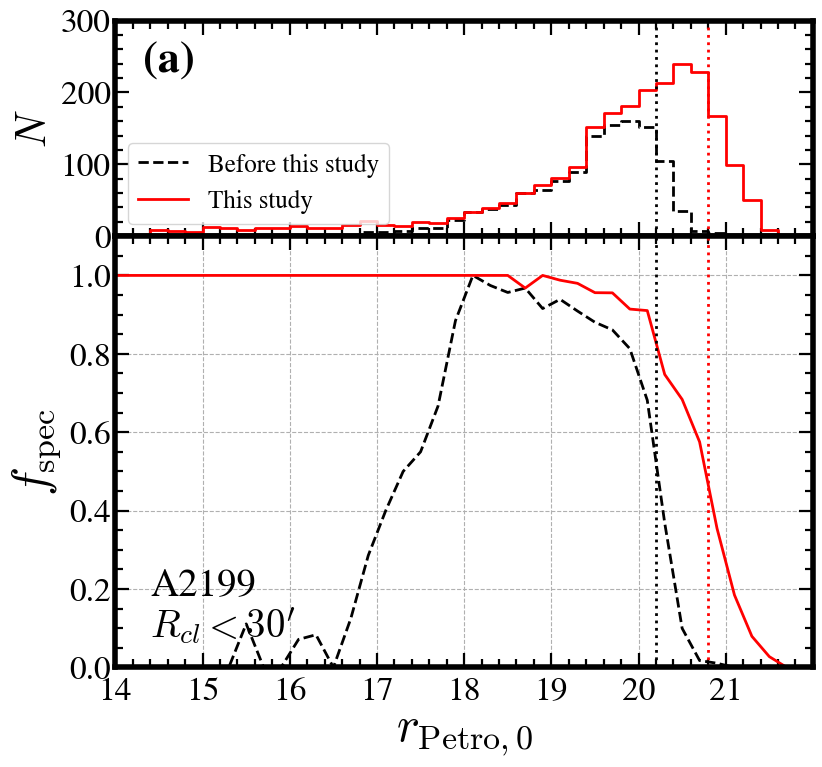

In [3]:
cluster_id = "A2199"

# Galaxies within 30 arcmin; subset whose redshift was known before this study
cluster_data = df[df['p_radgal'] < 30]
flagged_data = cluster_data[cluster_data['Song2017_Flag'] == 'Y']

# Magnitude bins
bin_width = 0.2
bin_edges = np.arange(12, 22 + bin_width, bin_width)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# ---- All galaxies: total and with redshift, per bin ----
bin_all = pd.cut(cluster_data['p_petromag_r_0'], bins=bin_edges, include_lowest=True)
total_all = bin_all.value_counts(sort=False).values
non99_all = cluster_data.groupby(bin_all)['z_tot_z'].apply(lambda x: (x != -9.0).sum()).values
frac_all = non99_all / total_all

# ---- Redshifts available before this study, relative to the same totals ----
bin_flag = pd.cut(flagged_data['p_petromag_r_0'], bins=bin_edges, include_lowest=True)
non99_flag = flagged_data.groupby(bin_flag)['z_tot_z'].apply(lambda x: (x != -9.0).sum()).values
frac_flag = non99_flag / total_all

# Faintest bin with f_spec > 0.5
threshold_val50_all = next((c for c, f in zip(bin_centers[::-1], frac_all[::-1]) if f > 0.50), None)
threshold_val50_flag = next((c for c, f in zip(bin_centers[::-1], frac_flag[::-1]) if f > 0.50), None)

# ---- Plot ----
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(15 * 0.6, 12 * 0.7),
    gridspec_kw={'height_ratios': [1.5, 3], 'hspace': 0},
    sharex=True
)

# Top: number of redshifts per bin
ax_top.step(bin_centers, non99_flag, where='mid', color='black', linestyle='--', lw=2, label='Before this study')
ax_top.step(bin_centers, non99_all, where='mid', color='red', linestyle='-', lw=2, label='This study')
ax_top.set_ylabel('$N$', fontsize=30)
ax_top.set_ylim(0, 300)
ax_top.tick_params(which='both', top=True, right=True, labelsize=24)
ax_top.xaxis.set_minor_locator(MultipleLocator(0.2))
ax_top.set_yticks([0, 100, 200, 300])
ax_top.legend(loc='lower left', fontsize=18)
ax_top.text(0.04, 0.90, '(a)', transform=ax_top.transAxes, fontsize=32, fontweight='bold', ha='left', va='top')

# Bottom: spectroscopic completeness
ax_bot.plot(bin_centers, frac_flag, '--', color='black', lw=2, label='$f_{spec}$ Before this study')
ax_bot.plot(bin_centers, frac_all, '-', color='red', lw=2, label='$f_{spec}$ This study')
ax_bot.set_xlim(14, 22)
ax_bot.set_xticks(np.arange(14, 22, 1))
ax_bot.set_xlabel(r'$r_{\mathrm{Petro,0}}$', fontsize=35)
ax_bot.set_ylabel(r'$f_{\mathrm{spec}}$', fontsize=35)
ax_bot.set_ylim(0, 1.1)
ax_bot.xaxis.set_minor_locator(MultipleLocator(0.2))
ax_bot.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax_bot.grid(which='major', axis='x', linestyle='--', linewidth=0.8)
ax_bot.grid(which='major', axis='y', linestyle='--', linewidth=0.8)
ax_bot.tick_params(which='both', top=True, right=True, labelsize=24)

# f_spec = 0.5 limits (drawn at the faint edge of the bin)
if threshold_val50_flag is not None:
    ax_top.axvline(threshold_val50_flag + 0.5 * bin_width, color='black', linestyle=':', linewidth=2)
    ax_bot.axvline(threshold_val50_flag + 0.5 * bin_width, color='black', linestyle=':', linewidth=2)
if threshold_val50_all is not None:
    ax_top.axvline(threshold_val50_all + 0.5 * bin_width, color='red', linestyle=':', linewidth=2)
    ax_bot.axvline(threshold_val50_all + 0.5 * bin_width, color='red', linestyle=':', linewidth=2)

ax_bot.text(0.05, 0.15, cluster_id, transform=ax_bot.transAxes, fontsize=28, ha='left', va='bottom')
ax_bot.text(0.05, 0.05, r'$R_{cl}<30^\prime$', transform=ax_bot.transAxes, fontsize=28, ha='left', va='bottom')

for spine in ax_top.spines.values(): spine.set_linewidth(4)
for spine in ax_bot.spines.values(): spine.set_linewidth(4)

## 2. Completeness map on the sky (r_Petro,0 < 20.5)

f_spec in 10′ × 10′ cells around the cluster centre, with the 1-D projections along RA and Dec. White circles and contours show the members and their density; the orange and red circles are R200 and R500.

/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_16355/4005580831.py:139: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.87, 1])


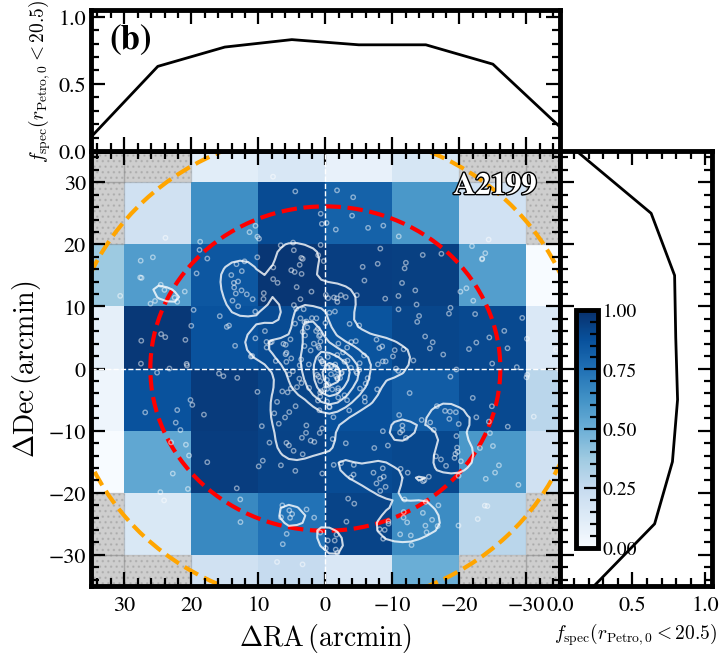

In [4]:
import matplotlib.patheffects as patheffects
from matplotlib import gridspec
from scipy.stats import binned_statistic_2d, binned_statistic, gaussian_kde

TARGET = 'A2199'
bin_width = 10          # arcmin

# Magnitude-limited sample
df_speccomp = df[df['p_petromag_r_0'] < 20.5]
df_speccomp_target = df_speccomp

# Cluster centre, redshift, R200 / R500 (Mpc -> arcmin)
central_row = hecs_vac_data[hecs_vac_data['CLID'] == TARGET]
central_ra = central_row['RA'].values[0]
central_dec = central_row['DEC'].values[0]
z = central_row['Z'].values[0]
r200 = central_row['R200'].values[0]
r500 = central_row['R500'].values[0]

d_a = cosmo.angular_diameter_distance(z).to(u.Mpc).value
r200_arcmin = (r200 / d_a) * (180 / np.pi) * 60
r500_arcmin = (r500 / d_a) * (180 / np.pi) * 60

# Offsets from the cluster centre in arcmin (RA offset scaled by cos Dec)
ra_values = df_speccomp_target['p_ra'].values
dec_values = df_speccomp_target['p_dec'].values
central_coord = SkyCoord(ra=central_ra * u.degree, dec=central_dec * u.degree, frame='icrs')
coords_all = SkyCoord(ra=ra_values * u.degree, dec=dec_values * u.degree, frame='icrs')

ra_diff_arcmin = (coords_all.ra.deg - central_coord.ra.deg) * np.cos(np.radians(central_coord.dec.deg)) * 60
dec_diff_arcmin = (coords_all.dec.deg - central_coord.dec.deg) * 60

df_member = pd.DataFrame({
    'RA_diff_arcmin': ra_diff_arcmin,
    'DEC_diff_arcmin': dec_diff_arcmin,
    'z_tot_z': df_speccomp_target['z_tot_z']
})

# 2-D and 1-D completeness (mean of "has redshift" per cell)
ra_bins = np.arange(-60, 60 + bin_width, bin_width)
dec_bins = np.arange(-60, 60 + bin_width, bin_width)

spec_fraction_2d, xedges, yedges, binnumber = binned_statistic_2d(
    df_member['RA_diff_arcmin'], df_member['DEC_diff_arcmin'],
    values=(df_member['z_tot_z'] != -9).astype(int),
    statistic='mean', bins=[ra_bins, dec_bins]
)
spec_fraction_ra, _, _ = binned_statistic(
    df_member['RA_diff_arcmin'], (df_member['z_tot_z'] != -9).astype(int),
    statistic='mean', bins=ra_bins
)
spec_fraction_dec, _, _ = binned_statistic(
    df_member['DEC_diff_arcmin'], (df_member['z_tot_z'] != -9).astype(int),
    statistic='mean', bins=dec_bins
)
ra_bin_centers = 0.5 * (ra_bins[1:] + ra_bins[:-1])
dec_bin_centers = 0.5 * (dec_bins[1:] + dec_bins[:-1])

# ---- Figure: main map + top / right projections ----
fig = plt.figure(figsize=(15 * 0.6, 12 * 0.6))
gs = gridspec.GridSpec(2, 2, width_ratios=[4, 1.3], height_ratios=[1.3, 4], hspace=0.0, wspace=0.0)

ax_main = fig.add_subplot(gs[1, 0])
masked_spec_fraction = np.ma.masked_invalid(spec_fraction_2d.T)
c = ax_main.pcolormesh(xedges, yedges, masked_spec_fraction, cmap='Blues', shading='auto', vmin=0, vmax=1)
c.cmap.set_bad(color='lightgray', alpha=0.3)

# Hatch cells without galaxies
for xi in range(len(xedges) - 1):
    for yi in range(len(yedges) - 1):
        if np.isnan(spec_fraction_2d[xi, yi]):
            rect = plt.Rectangle(
                (xedges[xi], yedges[yi]),
                xedges[xi + 1] - xedges[xi],
                yedges[yi + 1] - yedges[yi],
                color='gray', alpha=0.3, hatch='...', edgecolor=None
            )
            ax_main.add_patch(rect)

# Members: positions and KDE density contours
df_members_y = df_speccomp_target[df_speccomp_target['member'] == 'Y']
ra_members_y = df_members_y['p_ra'].values
dec_members_y = df_members_y['p_dec'].values
coords_members_y = SkyCoord(ra=ra_members_y * u.degree, dec=dec_members_y * u.degree, frame='icrs')
ra_diff_members_y = (coords_members_y.ra.deg - central_coord.ra.deg) * np.cos(np.radians(central_coord.dec.deg)) * 60
dec_diff_members_y = (coords_members_y.dec.deg - central_coord.dec.deg) * 60

ax_main.scatter(ra_diff_members_y, dec_diff_members_y, marker='o', facecolors='none', edgecolors='white', alpha=0.5, s=10, zorder=2)

kde_data = np.vstack([ra_diff_members_y, dec_diff_members_y])
k = gaussian_kde(kde_data, bw_method=0.15)
xi, yi = np.mgrid[ra_bins.min():ra_bins.max():100j, dec_bins.min():dec_bins.max():100j]
zi = k(np.vstack([xi.flatten(), yi.flatten()])).reshape(xi.shape)
ax_main.contour(xi, yi, zi, levels=6, colors='white', linewidths=1.5, alpha=0.8)

# R200 and R500 circles
ax_main.add_artist(plt.Circle((0, 0), r200_arcmin, color='orange', linestyle='--', linewidth=3, fill=False))
ax_main.add_artist(plt.Circle((0, 0), r500_arcmin, color='red', linestyle='--', linewidth=3, fill=False))

ax_main.axhline(0, color='white', linestyle='--', linewidth=1)
ax_main.axvline(0, color='white', linestyle='--', linewidth=1)
ax_main.set_xlim([-35, 35])
ax_main.set_ylim([-35, 35])
ax_main.set_xlabel(r'$\Delta \mathrm{RA} \, (\mathrm{arcmin})$', fontsize=20)
ax_main.set_ylabel(r'$\Delta \mathrm{Dec} \, (\mathrm{arcmin})$', fontsize=20)
ax_main.tick_params(which='both', top=True, right=True, labelsize=16)
ax_main.minorticks_on()
ax_main.invert_xaxis()
ax_main.text(
    0.95, 0.95, f'{TARGET}', ha='right', va='top', transform=ax_main.transAxes, fontsize=22, fontweight='bold',
    color='white', path_effects=[patheffects.withStroke(linewidth=2, foreground="black")]
)

# Top: completeness vs. RA offset
ax_top = fig.add_subplot(gs[0, 0], sharex=ax_main)
ax_top.plot(ra_bin_centers, spec_fraction_ra, color='black', lw=2)
ax_top.set_ylabel(r'$f_{\mathrm{spec}}(r_\mathrm{Petro,0}<20.5)$', fontsize=14)
ax_top.set_yticks([0, 0.5, 1])
ax_top.set_ylim(0, 1.05)
ax_top.tick_params(labelbottom=False, labelsize=16)
ax_top.minorticks_on()
ax_top.text(0.04, 0.90, '(b)', transform=ax_top.transAxes, fontsize=25, fontweight='bold', ha='left', va='top')

# Right: completeness vs. Dec offset
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)
ax_right.plot(spec_fraction_dec, dec_bin_centers, color='black', lw=2)
ax_right.set_xlabel(r'$f_{\mathrm{spec}}(r_\mathrm{Petro,0}<20.5)$', fontsize=14)
ax_right.set_xticks([0, 0.5, 1])
ax_right.set_xlim(0, 1.05)
ax_right.tick_params(labelleft=False, labelsize=16)
ax_right.minorticks_on()

# Colour bar
cbar_ax = fig.add_axes([0.67, 0.2, 0.025, 0.33])
cbar = fig.colorbar(c, cax=cbar_ax)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1])
cbar.ax.tick_params(labelsize=14)

plt.tight_layout(rect=[0, 0, 0.87, 1])
plt.show()

## 3. Redshift distribution (R_cl < 30′)

Top: r-band magnitude vs. redshift for galaxies with a redshift, before this study (black) and newly measured here (red). Bottom: redshift histograms of all galaxies, of the new redshifts, and of the cluster members.

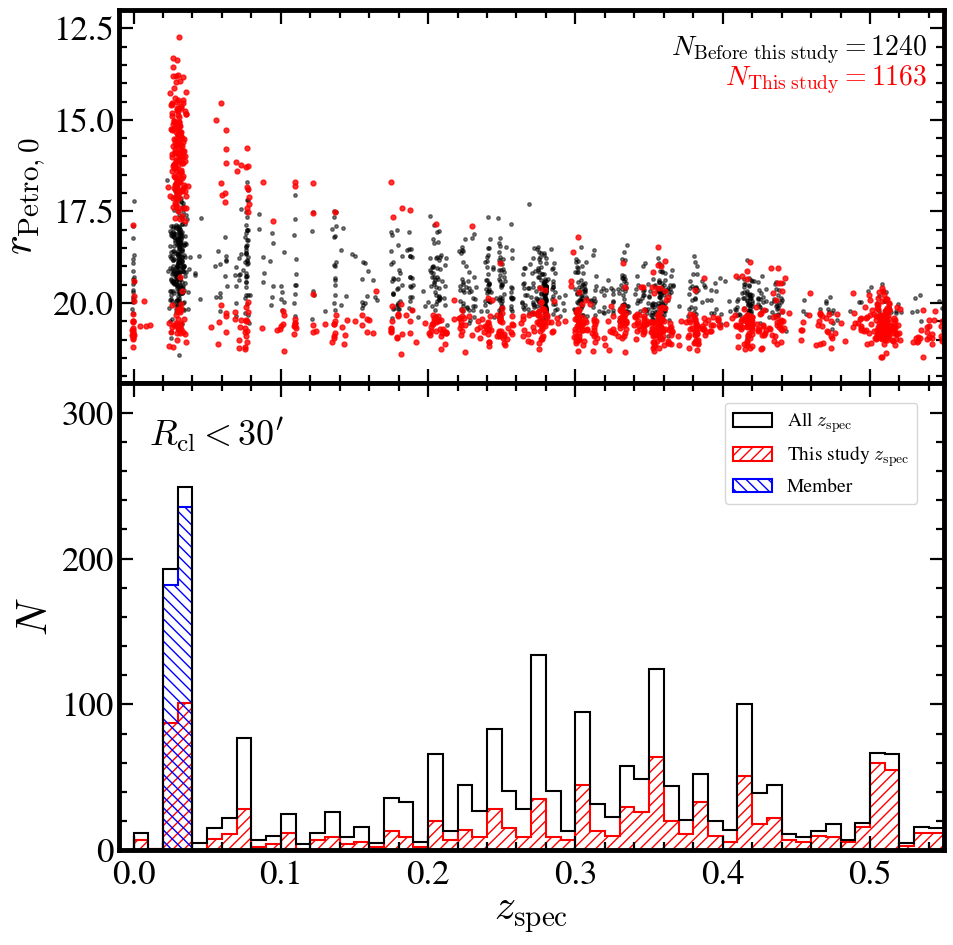

In [5]:
# Galaxies with a redshift within 30 arcmin; redshift bins of 0.01
bins = np.arange(0, 0.6 + 0.1/10, 0.1/10)
df_plot = df[(df['z_tot_z'] != -9.0) & (df['p_radgal'] <= 30)]

fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1, sharex=True, figsize=(10, 10), gridspec_kw={'height_ratios': [0.8, 1]}
)

mask_song = df_plot['Song2017_Flag'] == 'Y'      # redshift known before this study
mask_mine = df_plot['Song2017_Flag'] == 'N'      # new redshift from this study
mask_member = df_plot['member'] == 'Y'

# ---- Top: magnitude vs. redshift ----
ax_top.plot(df_plot.loc[mask_song, 'z_tot_z'], df_plot.loc[mask_song, 'p_petromag_r_0'],
            'o', color='black', markersize=2.5, alpha=0.5)
ax_top.plot(df_plot.loc[mask_mine, 'z_tot_z'], df_plot.loc[mask_mine, 'p_petromag_r_0'],
            'o', color='red', markersize=3.5, alpha=0.8)

N_before = mask_song.sum()
N_this = mask_mine.sum()
y0 = 0.85
ax_top.text(0.98, y0, fr"$N_\mathrm{{Before\ this\ study}} = {N_before}$",
            transform=ax_top.transAxes, fontsize=20, ha='right', va='bottom')
ax_top.text(0.98, y0 - 0.08, fr"$N_\mathrm{{This\ study}} = {N_this}$",
            transform=ax_top.transAxes, fontsize=20, color='red', ha='right', va='bottom')

ax_top.set_ylabel(r'$r_\mathrm{Petro,0}$', fontsize=30)
ax_top.invert_yaxis()
ax_top.set_ylim(22.2, 12)

ax_bottom.annotate(r"$R_\mathrm{cl} < 30'$", xy=(0.2, 0.85), xycoords='axes fraction',
                   ha='right', va='bottom', fontsize=26)

# ---- Bottom: redshift histograms ----
ax_bottom.hist(df_plot['z_tot_z'], bins=bins, histtype='step',
               linewidth=1.5, color='black', label=r'All $z_\mathrm{spec}$')
ax_bottom.hist(df_plot.loc[mask_mine, 'z_tot_z'], bins=bins, histtype='stepfilled',
               edgecolor='red', facecolor='none', hatch='///',
               linewidth=1.5, label=r'This study $z_\mathrm{spec}$')
ax_bottom.hist(df_plot.loc[mask_member, 'z_tot_z'], bins=bins, histtype='stepfilled',
               edgecolor='blue', facecolor='none', hatch='\\\\\\',
               linewidth=1.5, label='Member')

ax_bottom.set_xlabel(r'$z_\mathrm{spec}$', fontsize=30)
ax_bottom.set_ylabel(r'$N$', fontsize=30)
ax_bottom.set_xlim(-0.01, 0.55)
ax_bottom.set_ylim(0, 320)
ax_bottom.legend(fontsize=14, loc='upper right', bbox_to_anchor=(0.98, 0.98))

for ax in (ax_top, ax_bottom):
    ax.tick_params(which='both', direction='in', top=True, right=True)
    ax.minorticks_on()

plt.tight_layout()
plt.subplots_adjust(hspace=0.0)
plt.show()